# **YOLOv8m Training Cells on PCB Componenets Detection**

In [4]:
# 1. Update to the latest Ultralytics version to get TAL memory-recovery updates
!pip install -U ultralytics

# 2. Configure PyTorch memory allocator to defragment CUDA segments
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# 3. Verify PyTorch detects your GPU
import torch
print(f"Using GPU: {torch.cuda.get_device_name(0)}" if torch.cuda.is_available() else "Warning: No GPU detected! Go to Runtime > Change runtime type and select T4 GPU.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.6 MB/s eta 0:00:00
Using GPU: Tesla T4


In [5]:
from ultralytics import hub

# Login using your Hub API Key
hub.login('ac1ba859ad64ec81abd3e7392f4ab87dcb15c151e2')


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
requirements: Ultralytics requirement ['hub-sdk>=0.0.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 6 packages in 300ms
Prepared 1 package in 21ms
Installed 1 package in 2ms
 + hub-sdk==0.0.24

requirements: AutoUpdate success ✅ 0.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Ultralytics HUB: New authentication successful ✅


True

In [6]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="6tGfCDaPS8NW7wRRtJbm")
project = rf.workspace("erl-n2gvo").project("component-detection-caevk")
version = project.version(1)
dataset = version.download("yolov8-obb")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.3/260.3 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 45.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to component-detection-1 in yolov8-obb:: 100%|██████████| 271/271 [00:00<00:00, 1643.79it/s]


In [3]:
from ultralytics import YOLO
model = YOLO('yolov8m-obb.pt')
results = model.train(
    data='/content/component-detection-1/data.yaml',
    epochs=200,
    batch=4,         # Keep at 4 for VRAM stability
    imgsz=1024,
    workers=4,
    cache=False,
    amp=True,
    patience=50,
    plots=True
)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/component-detection-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=

Exception in thread Thread-61 (retry_request):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/requests/models.py", line 820, in generate
    yield from self.raw.stream(chunk_size, decode_content=True)
  File "/usr/local/lib/python3.12/dist-packages/urllib3/response.py", line 1088, in stream
    yield from self.read_chunked(amt, decode_content=decode_content)
  File "/usr/local/lib/python3.12/dist-packages/urllib3/response.py", line 1248, in read_chunked
    self._update_chunk_length()
  File "/usr/local/lib/python3.12/dist-packages/urllib3/response.py", line 1178, in _update_chunk_length
    raise ProtocolError("Response ended prematurely") from None
urllib3.exceptions.ProtocolError: Response ended prematurely

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 10

     52/200       7.1G      0.899     0.7577     0.9435     0.0121        204       1024: 100% ━━━━━━━━━━━━ 31/31 2.0it/s 15.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 5.2it/s 0.4s
                   all          5        979       0.71      0.654       0.58      0.451

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss angle_loss  Instances       Size
     53/200       7.1G      0.894     0.7236     0.9347    0.01048        654       1024: 100% ━━━━━━━━━━━━ 31/31 2.1it/s 14.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 4.4it/s 0.5s
                   all          5        979      0.683      0.673      0.571      0.449

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss angle_loss  Instances       Size
     54/200       7.1G     0.8661     0.7251     0.9409   0.008896        987       1024: 100% ━━━━━━━━━━━━ 31/31 2.1it/s 15.1s
        

Exception in thread Thread-115 (retry_request):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/requests/models.py", line 820, in generate
    yield from self.raw.stream(chunk_size, decode_content=True)
  File "/usr/local/lib/python3.12/dist-packages/urllib3/response.py", line 1088, in stream
    yield from self.read_chunked(amt, decode_content=decode_content)
  File "/usr/local/lib/python3.12/dist-packages/urllib3/response.py", line 1248, in read_chunked
    self._update_chunk_length()
  File "/usr/local/lib/python3.12/dist-packages/urllib3/response.py", line 1178, in _update_chunk_length
    raise ProtocolError("Response ended prematurely") from None
urllib3.exceptions.ProtocolError: Response ended prematurely

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1

    105/200       7.1G     0.7626     0.5501      0.831   0.007913        331       1024: 100% ━━━━━━━━━━━━ 31/31 1.8it/s 17.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 3.6it/s 0.6s
                   all          5        979      0.815      0.562       0.58      0.462

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss angle_loss  Instances       Size
    106/200       7.1G     0.7359     0.5565     0.8371   0.007233        724       1024: 100% ━━━━━━━━━━━━ 31/31 2.1it/s 14.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 4.9it/s 0.4s
                   all          5        979      0.792       0.56      0.567      0.461

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss angle_loss  Instances       Size
    107/200       7.1G     0.7723     0.5636     0.8311   0.006924        949       1024: 100% ━━━━━━━━━━━━ 31/31 2.0it/s 15.5s
        

Extracting analytical data from: runs/obb/train-8

--- Raw Metrics (Final 5 Epochs) ---


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,train/angle_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,val/angle_loss,lr/pg0,lr/pg1,lr/pg2
145,146,2639.83,0.69107,0.48568,0.79983,0.00647,0.66088,0.53037,0.58954,0.47537,0.73595,0.63390,0.90928,0.00910,0.000217,0.000217,0.000217
146,147,2663.41,0.69860,0.48821,0.81094,0.00645,0.66259,0.51567,0.58020,0.47123,0.71469,0.62747,0.90968,0.00798,0.000213,0.000213,0.000213
147,148,2685.76,0.69739,0.48895,0.79250,0.00578,0.62014,0.55348,0.57515,0.46923,0.71517,0.62547,0.91043,0.00865,0.000209,0.000209,0.000209
148,149,2702.93,0.74023,0.50757,0.79331,0.00732,0.59610,0.69677,0.59717,0.48413,0.72219,0.62929,0.90566,0.00774,0.000206,0.000206,0.000206
149,150,2719.68,0.70884,0.49539,0.80362,0.00696,0.71125,0.72986,0.65456,0.52148,0.73690,0.62093,0.90525,0.00869,0.000202,0.000202,0.000202



--- Visual Plot: BoxP_curve.png ---


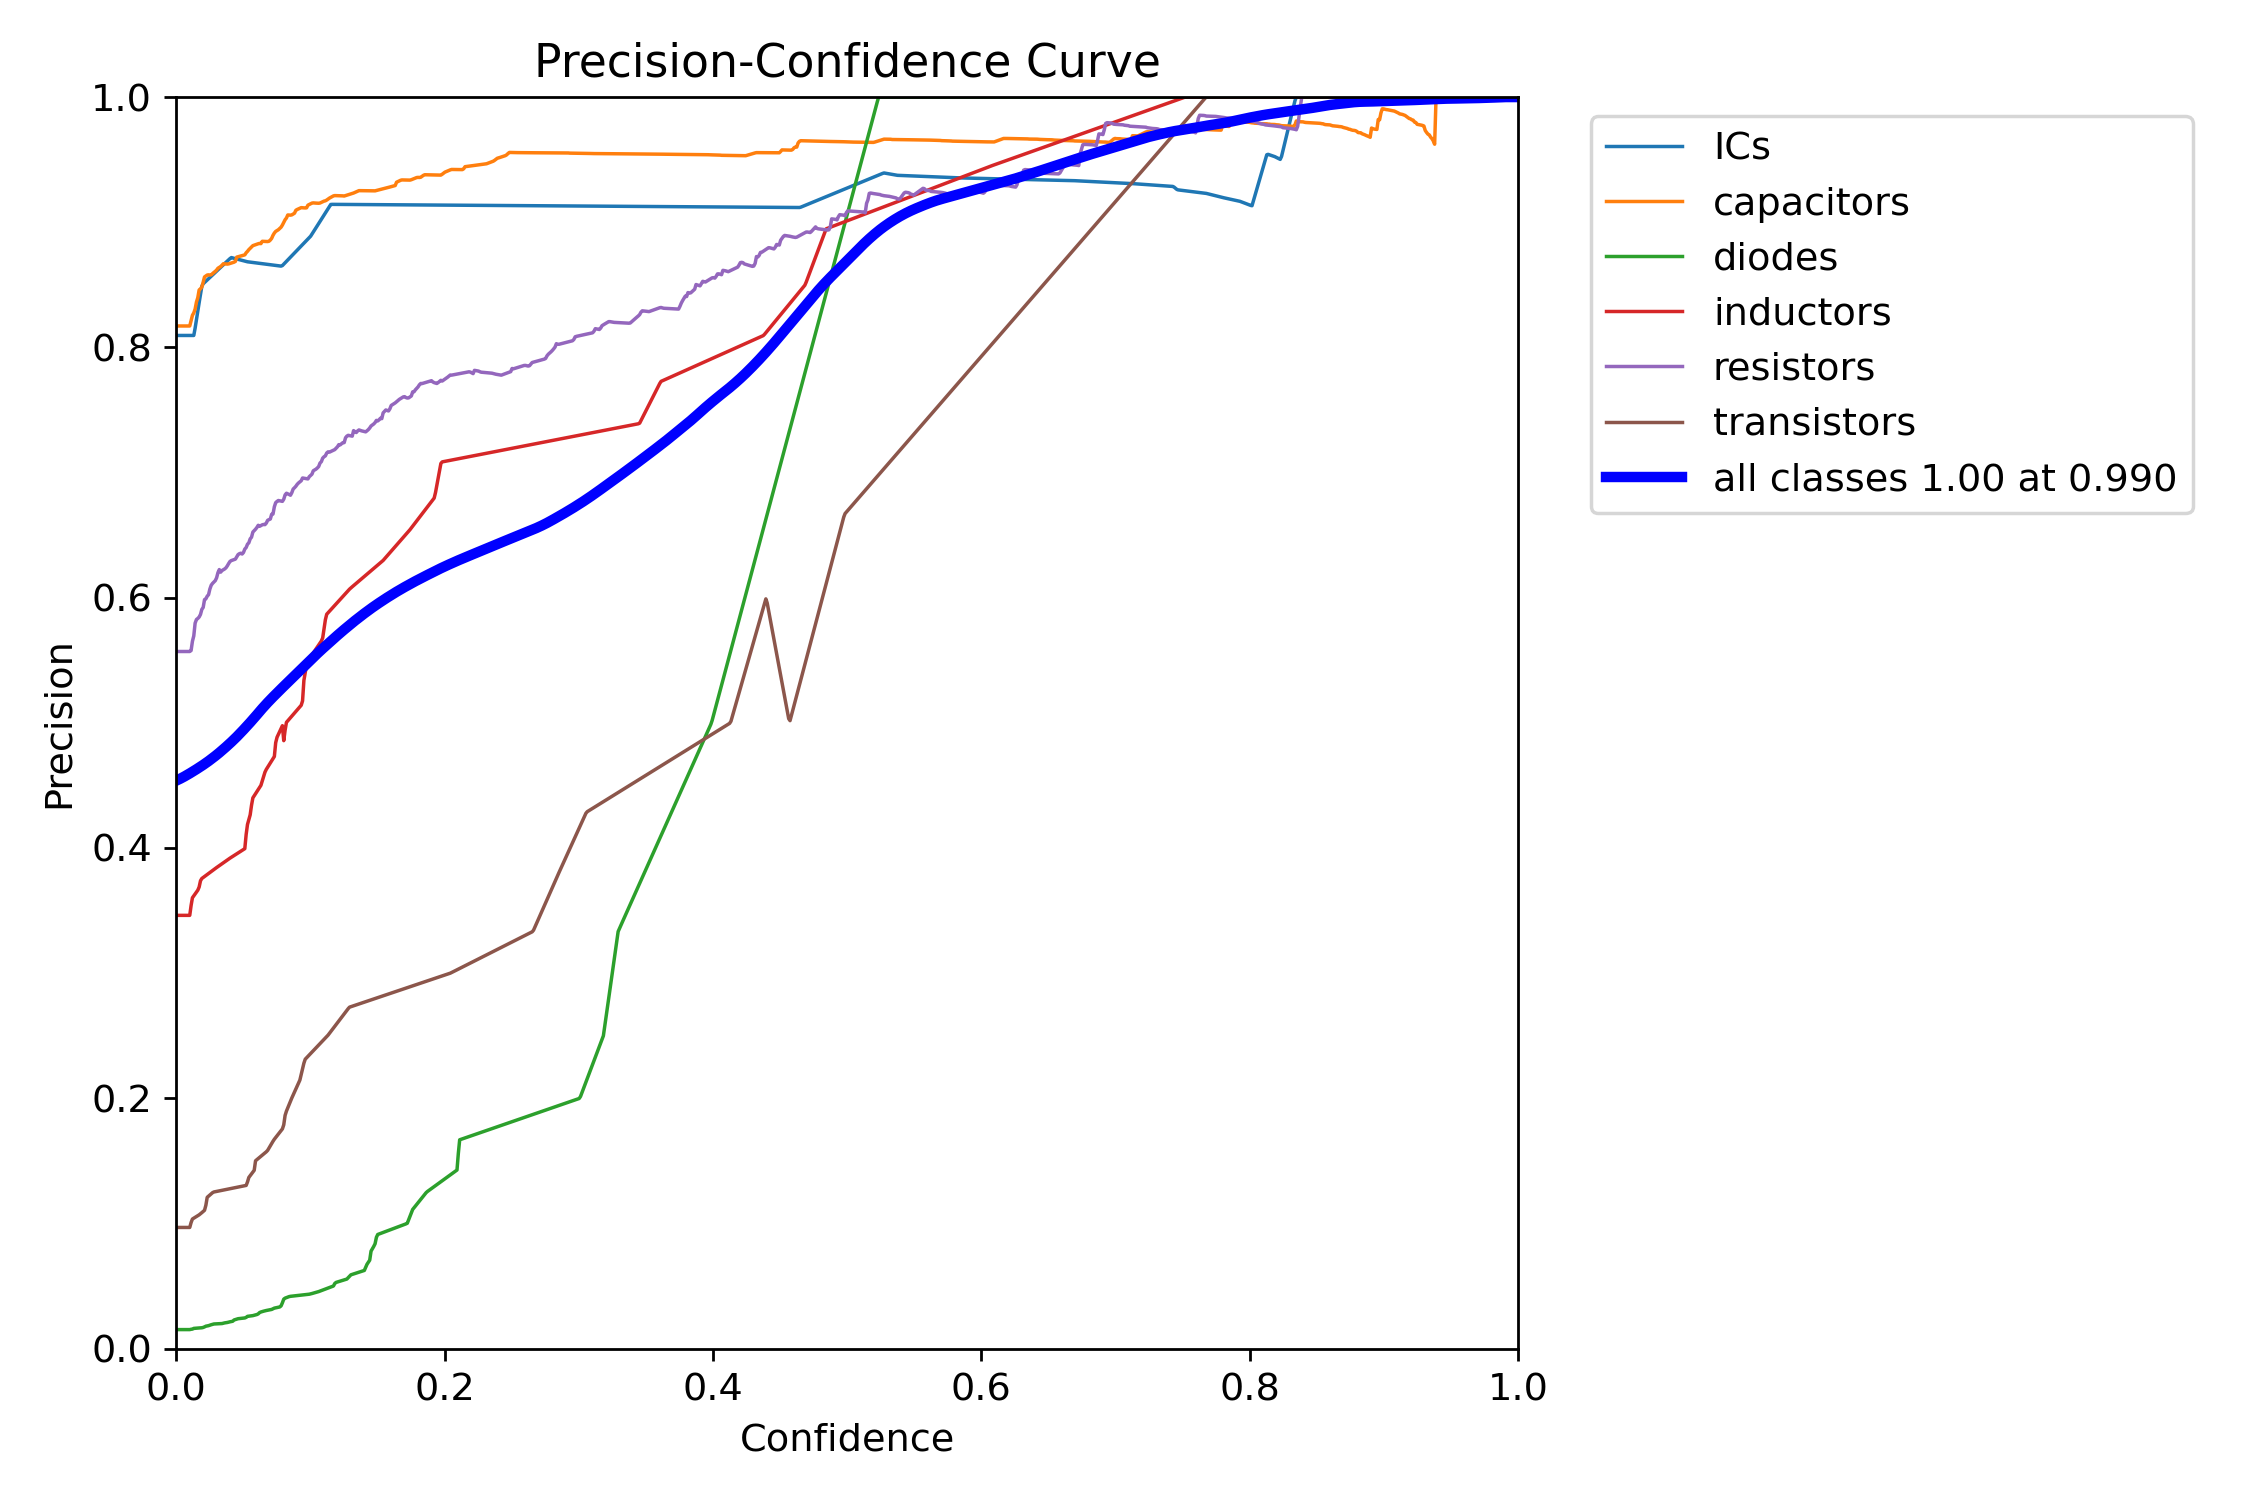


--- Visual Plot: BoxR_curve.png ---


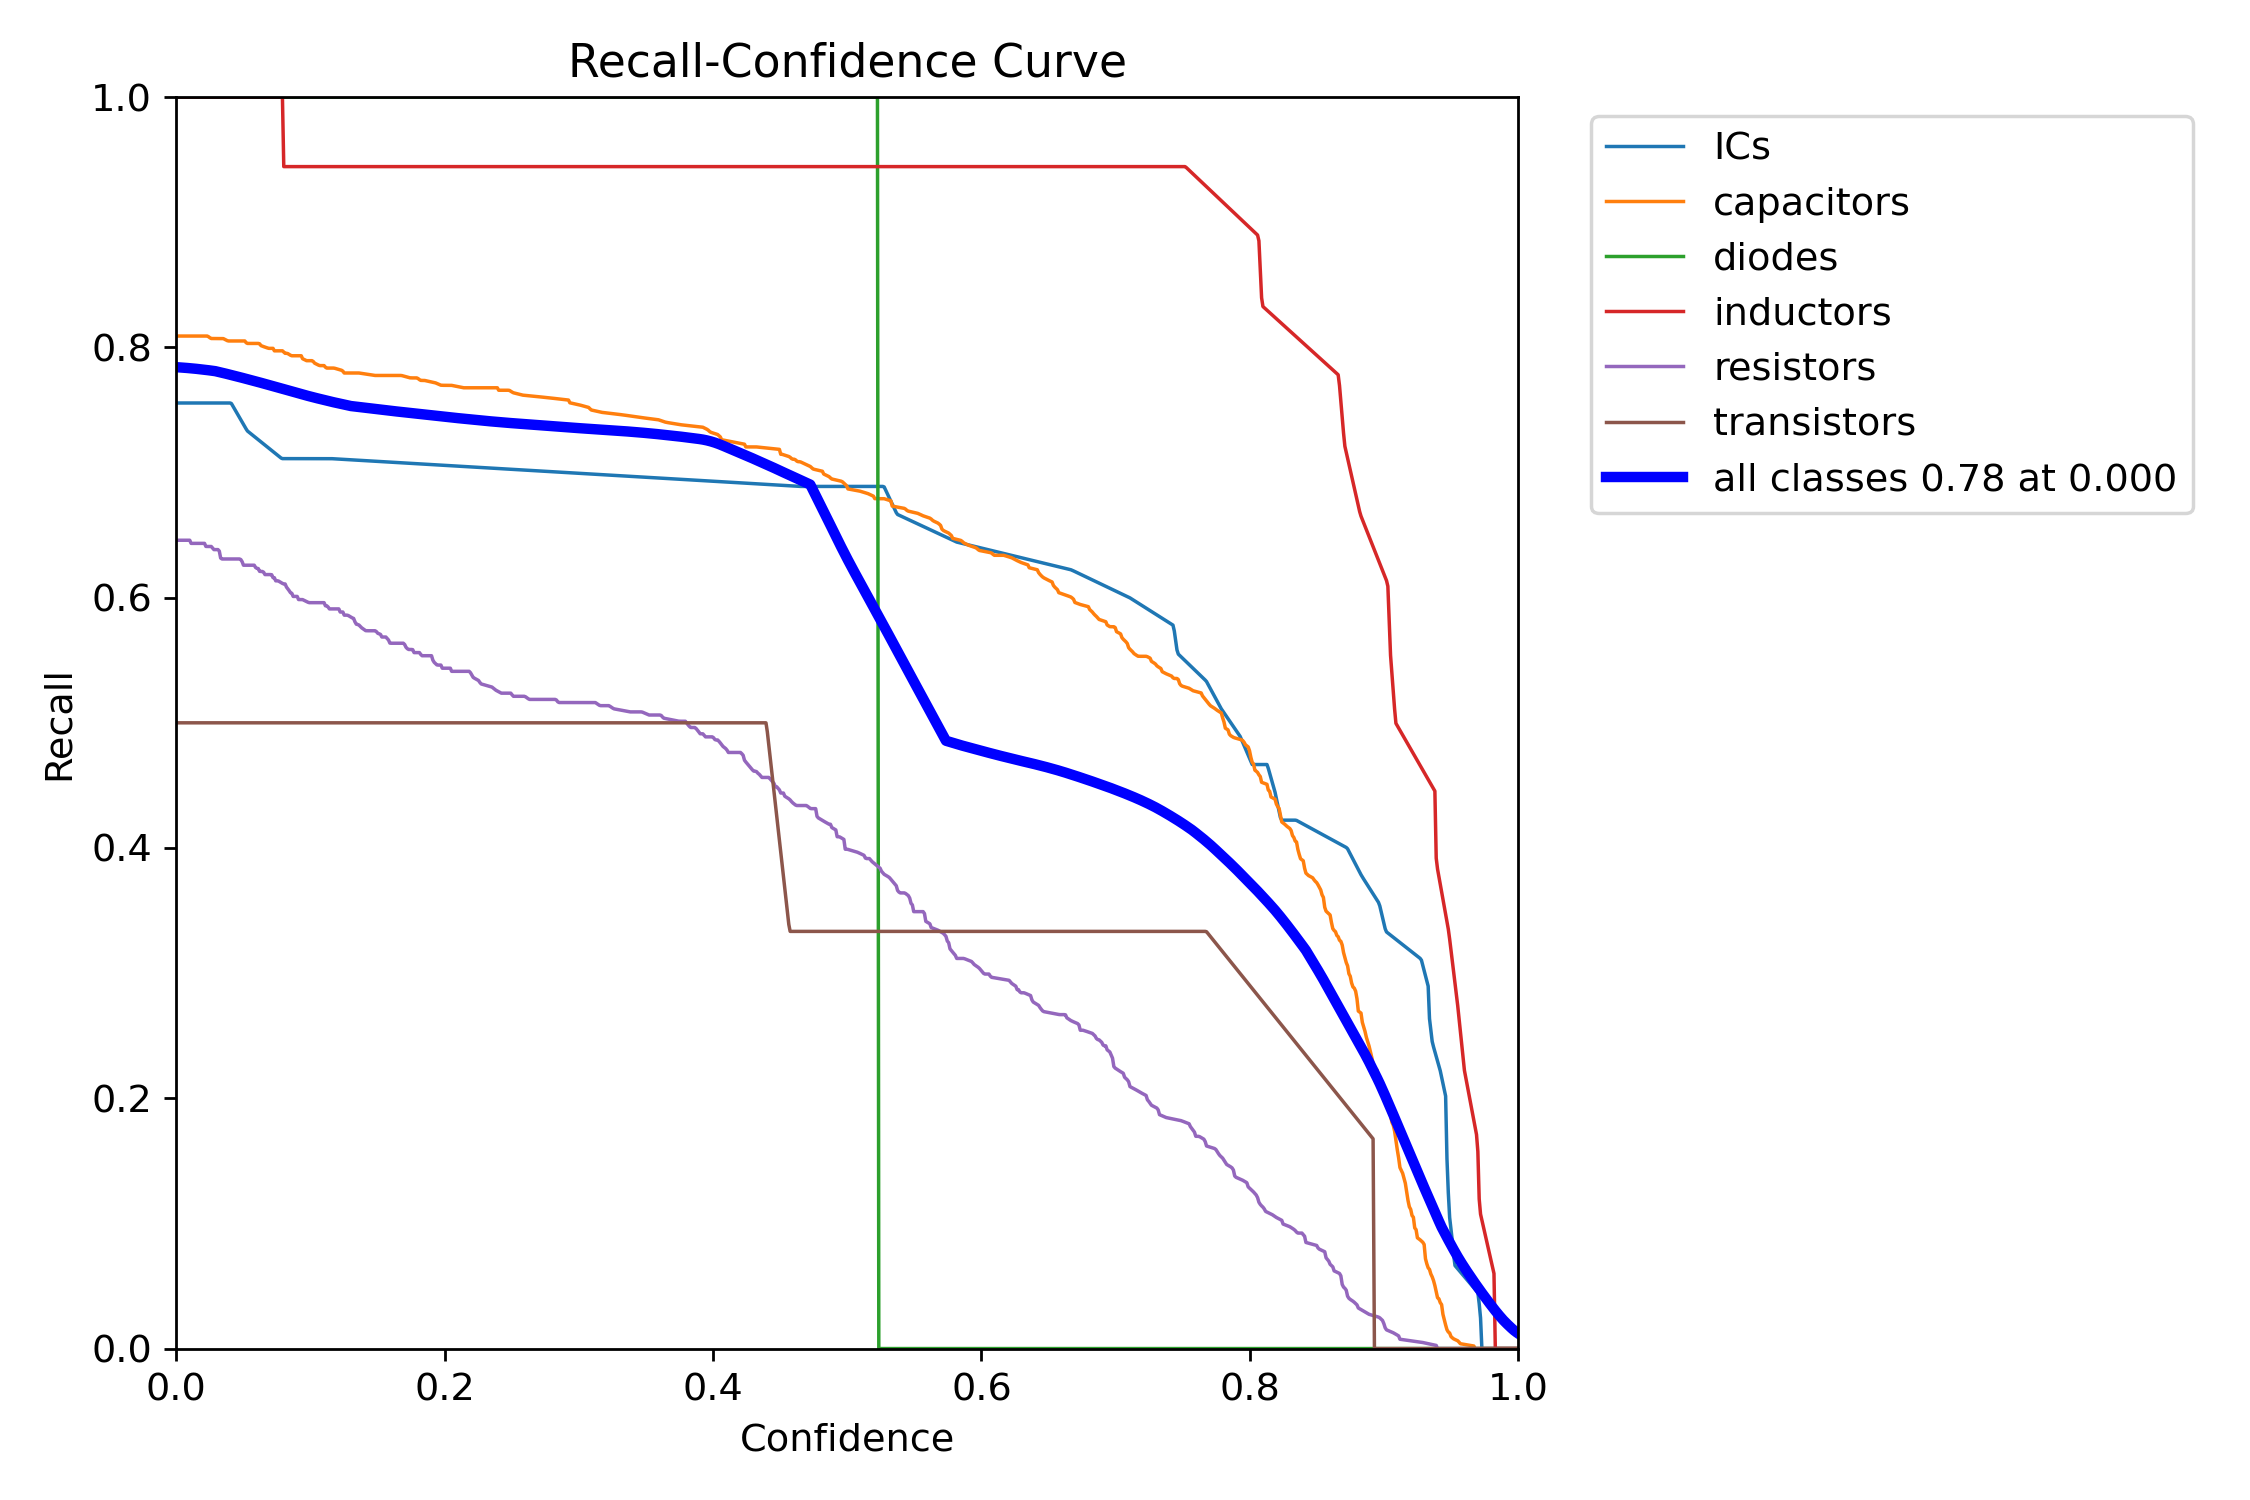


--- Visual Plot: results.png ---


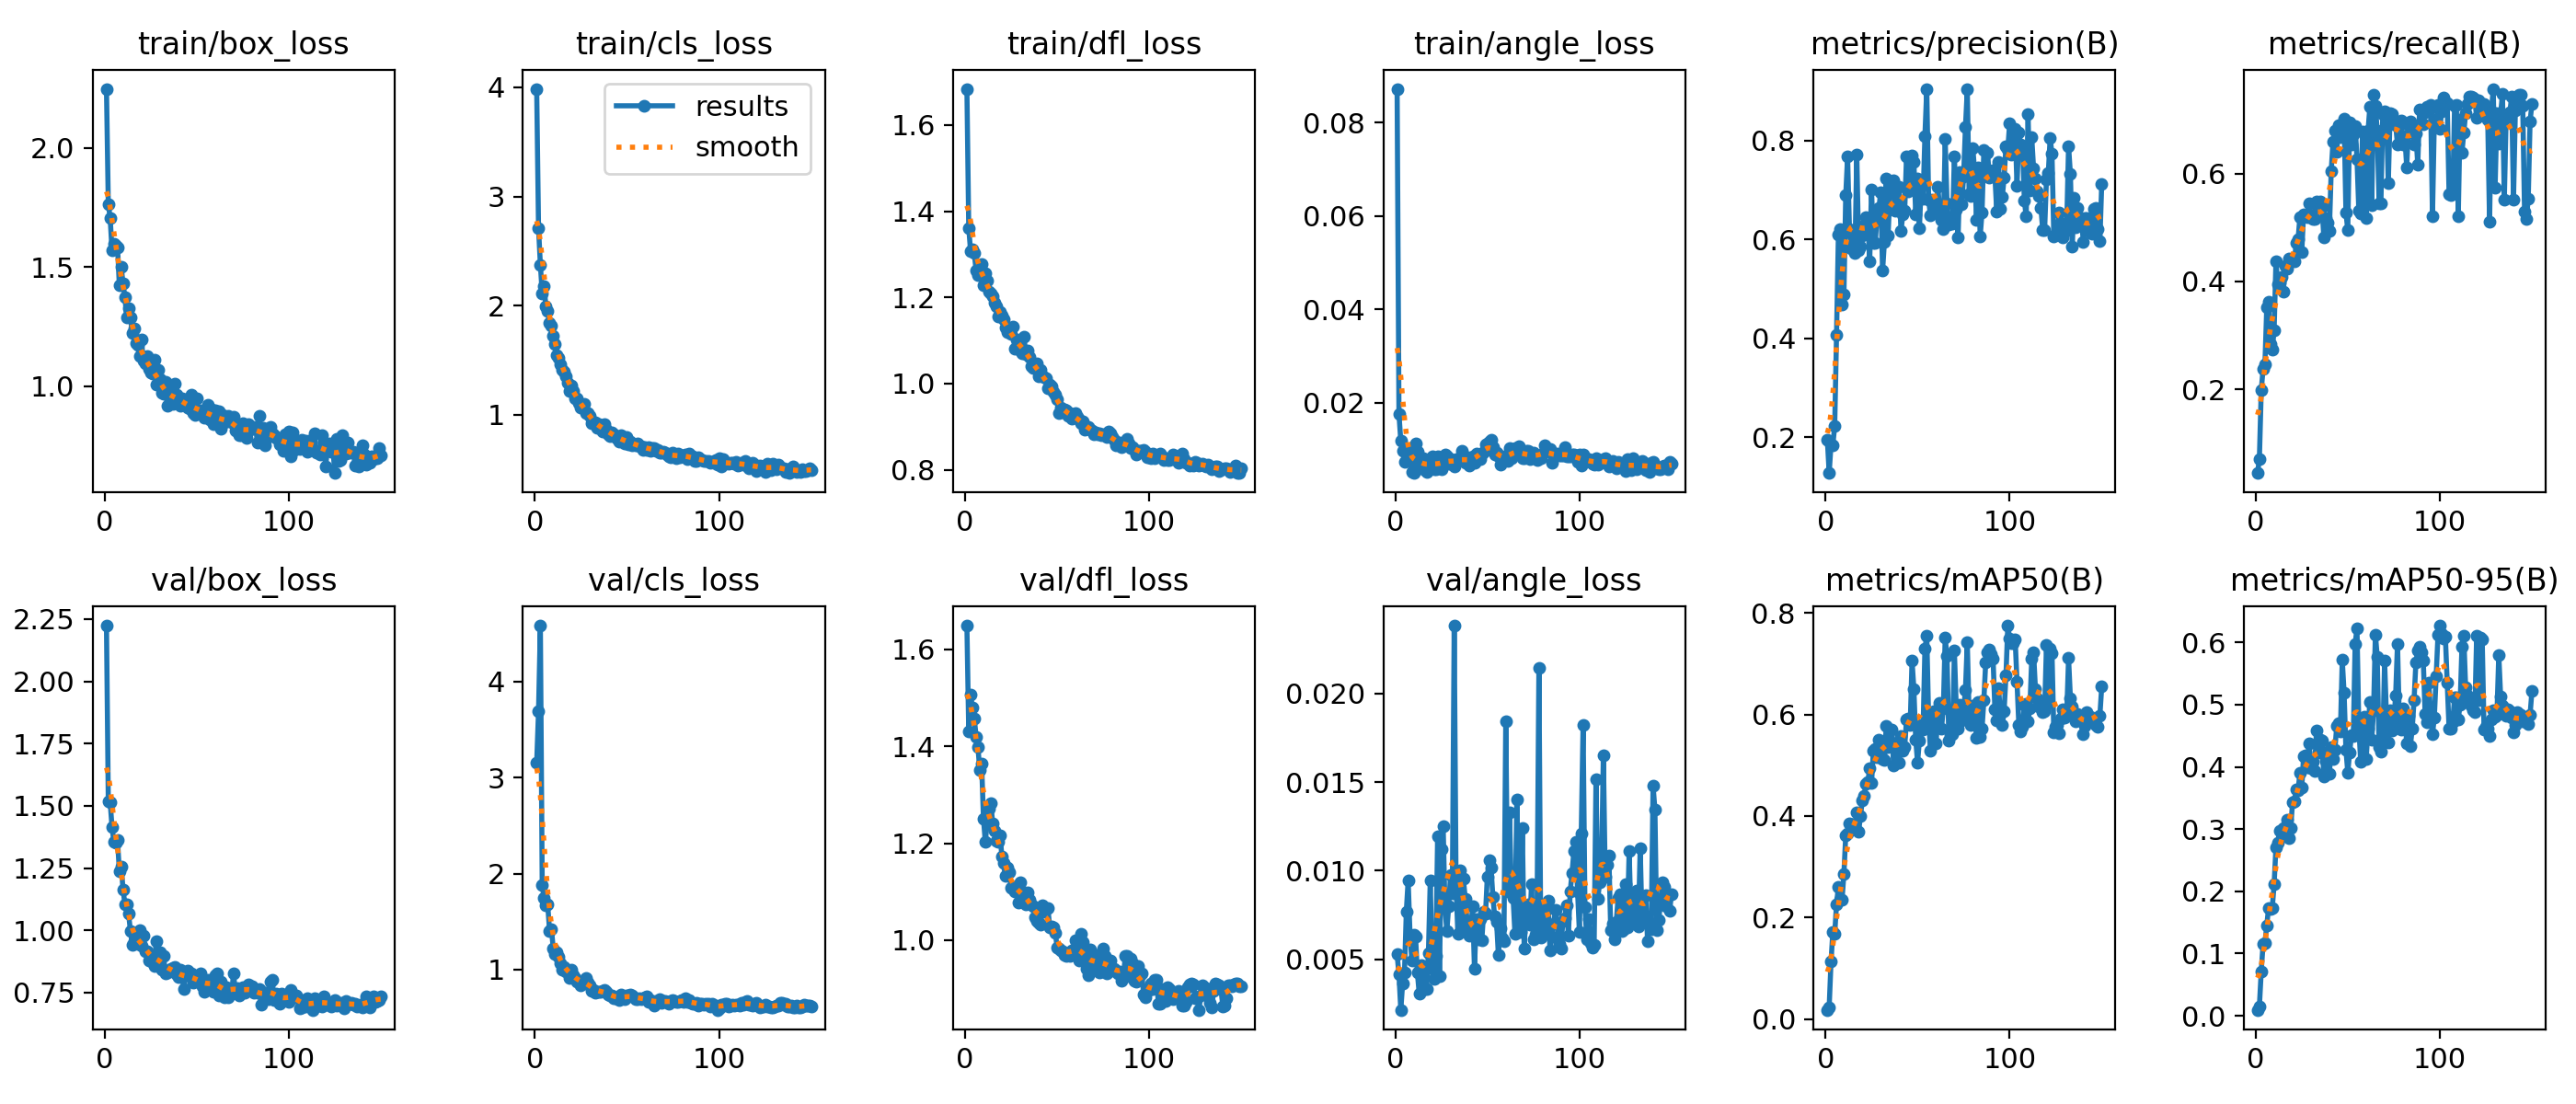


--- Visual Plot: BoxF1_curve.png ---


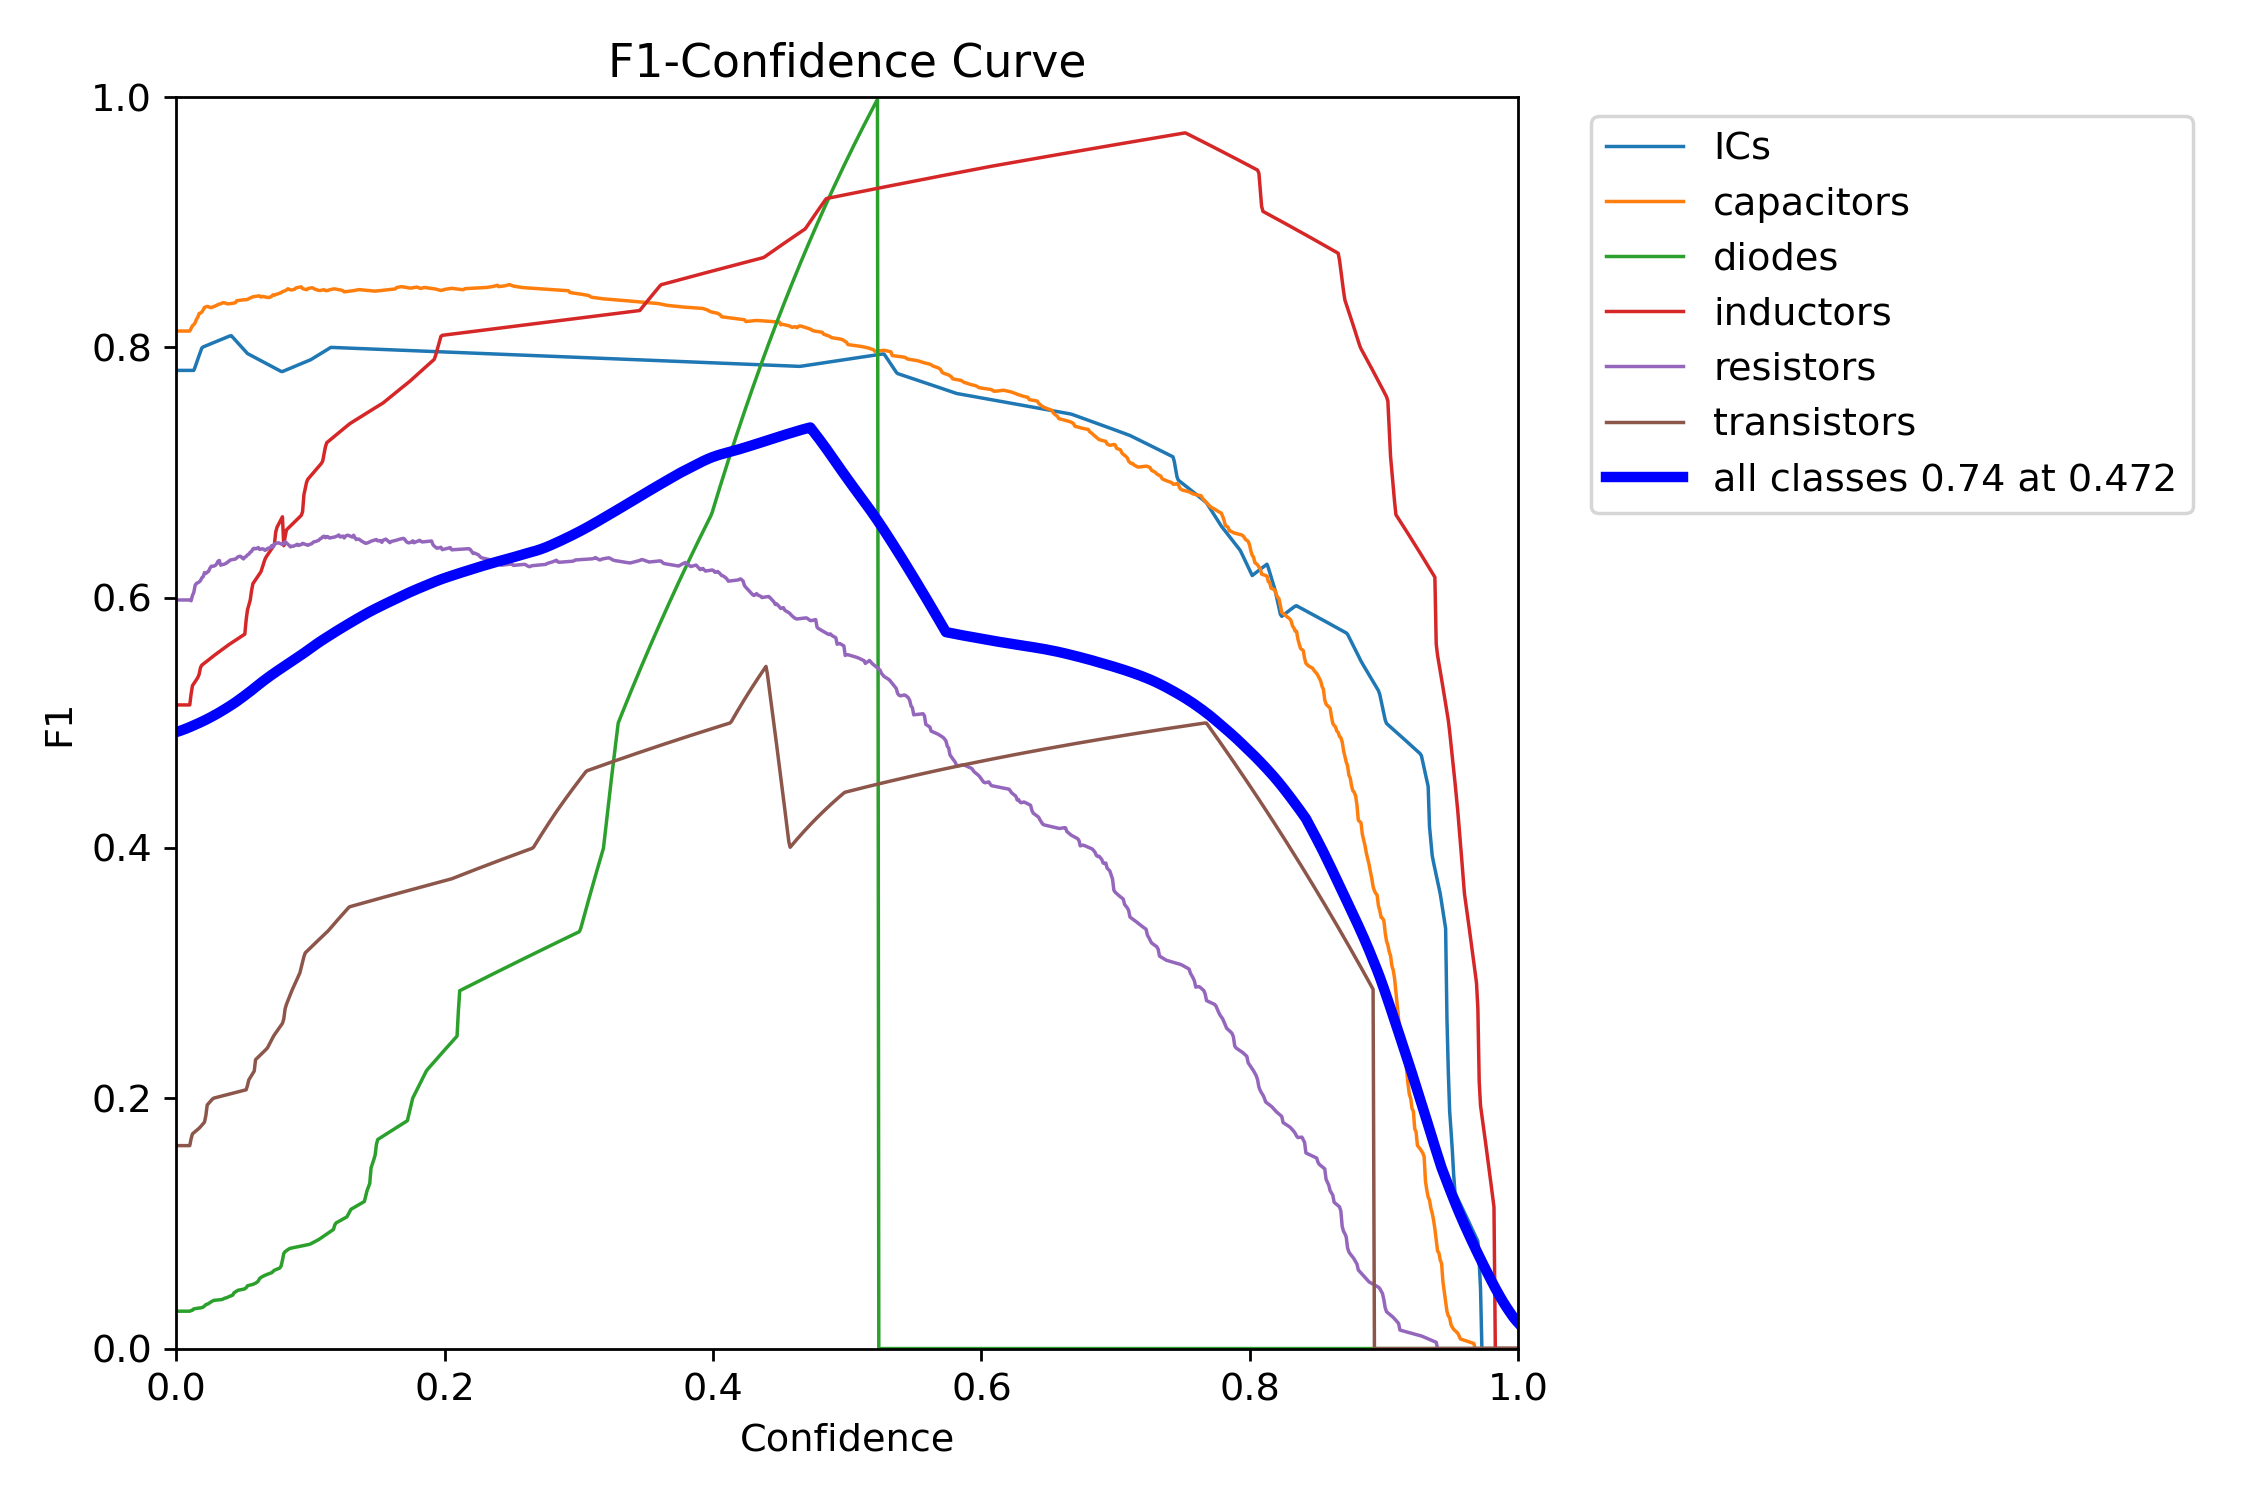


--- Visual Plot: BoxPR_curve.png ---


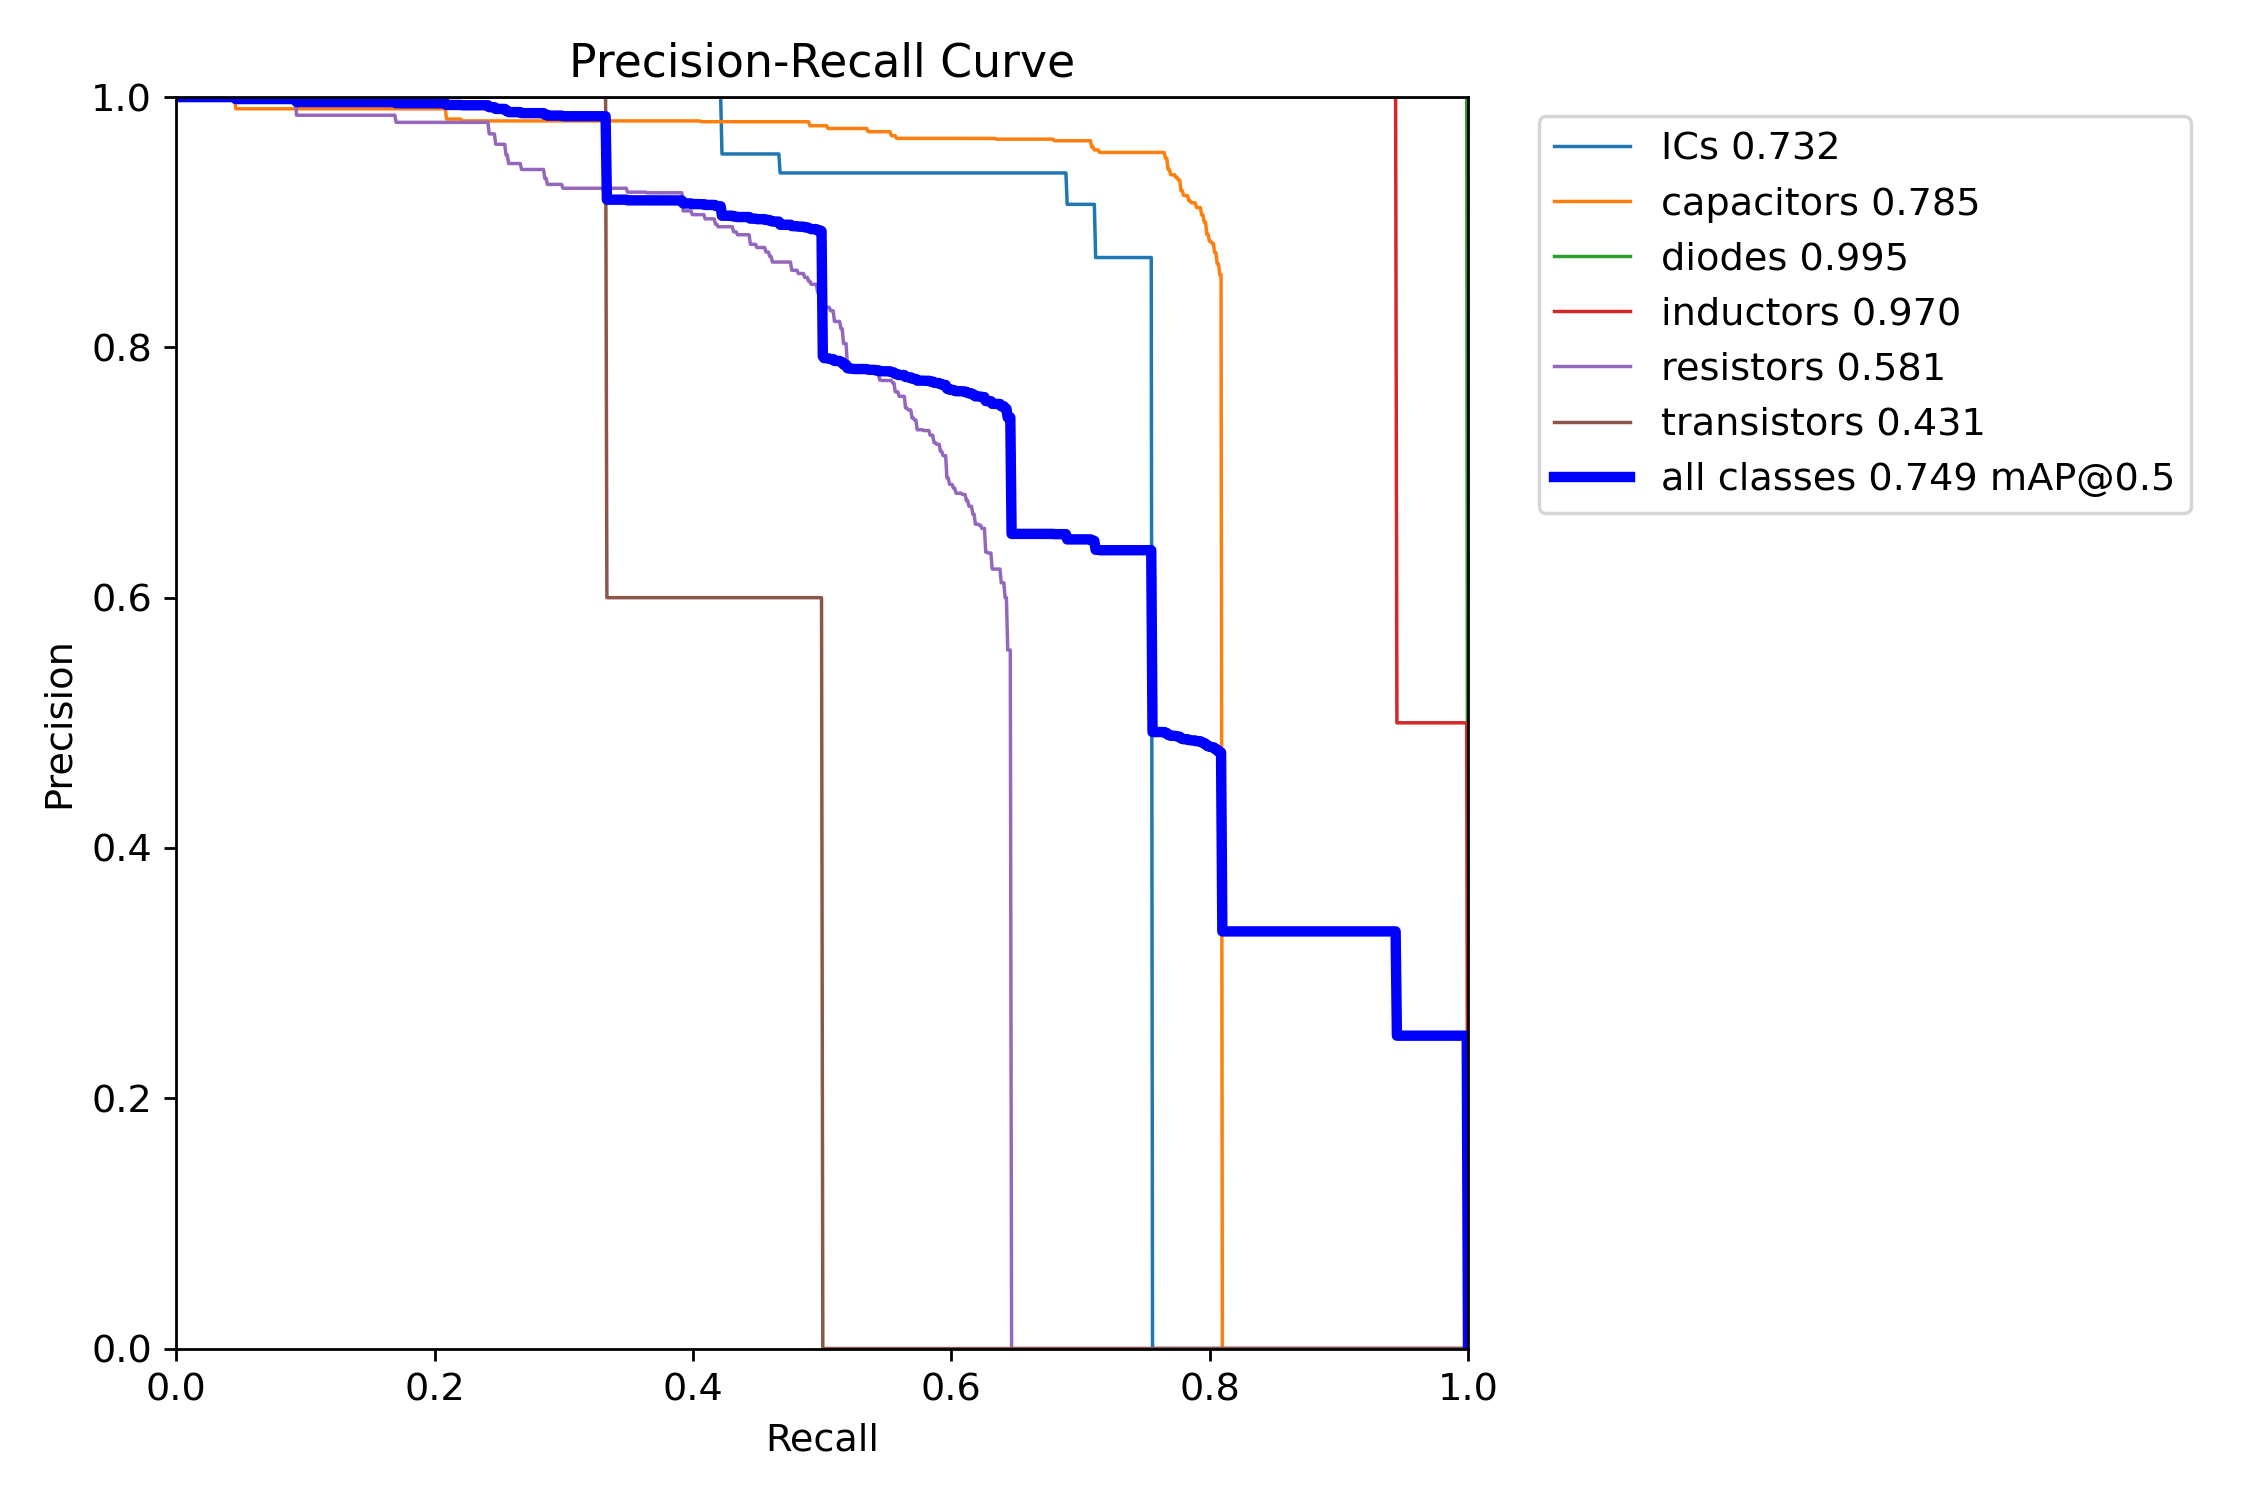


--- Visual Plot: confusion_matrix_normalized.png ---


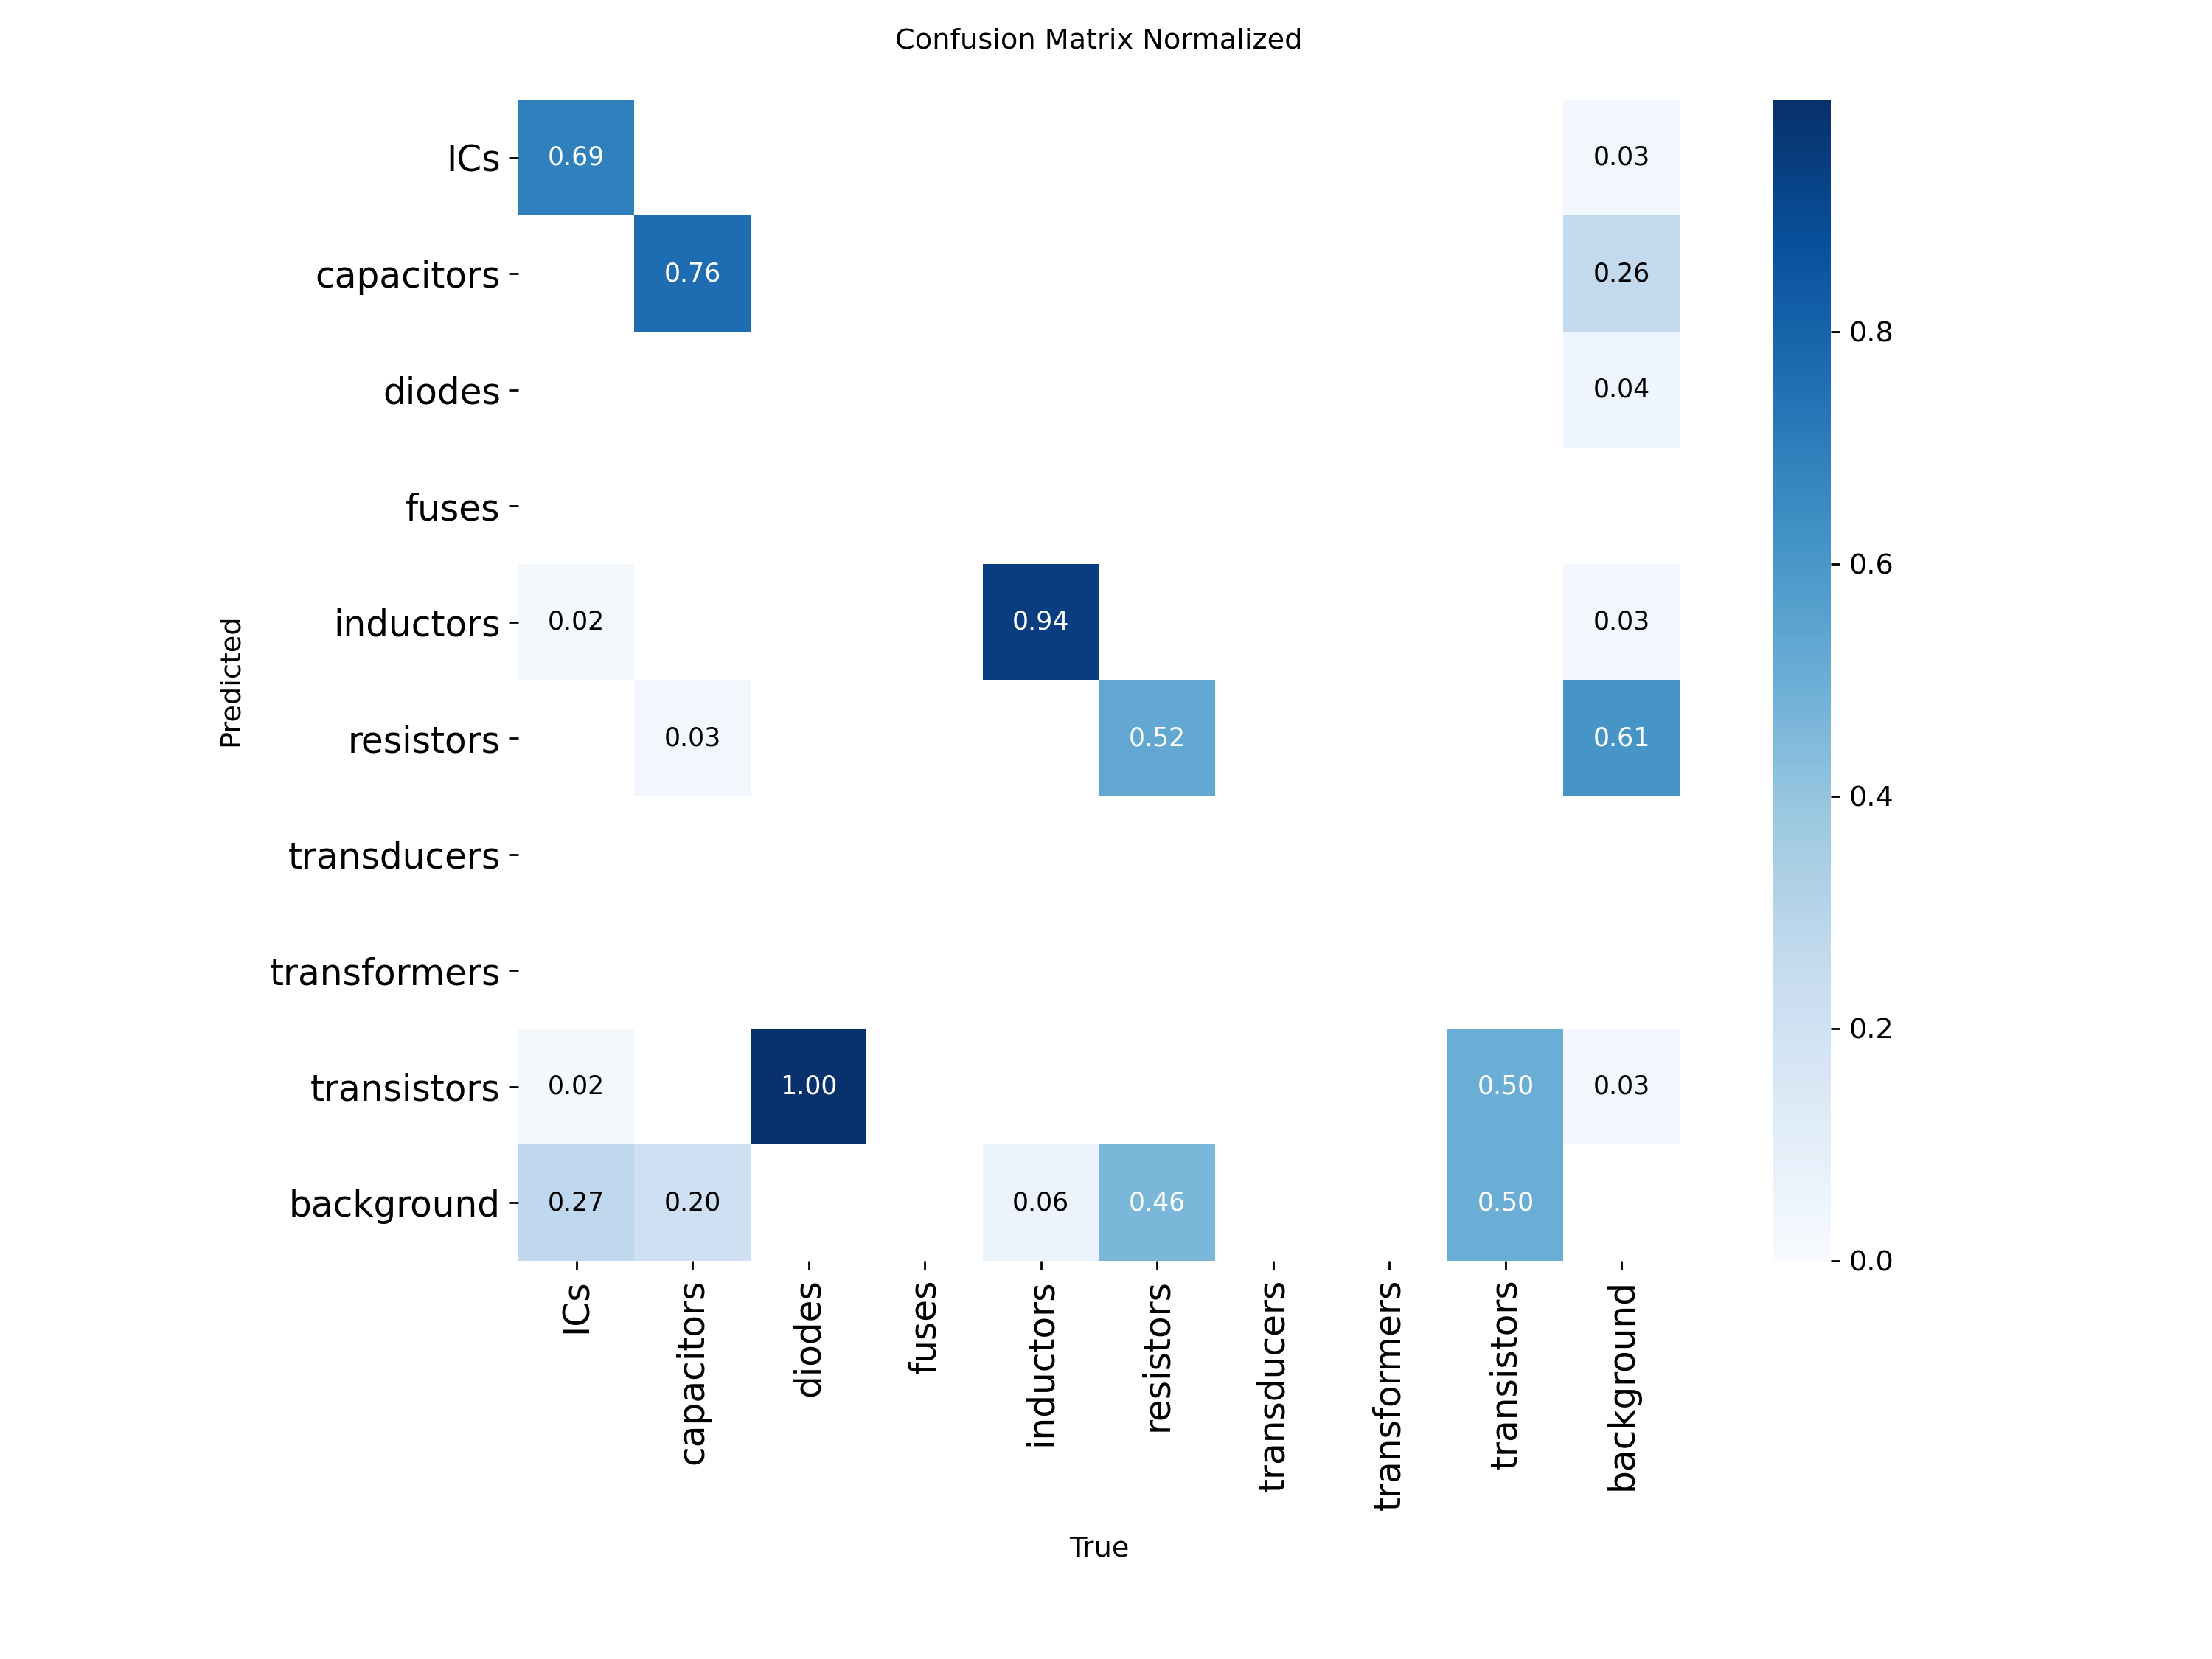


--- Visual Plot: confusion_matrix.png ---


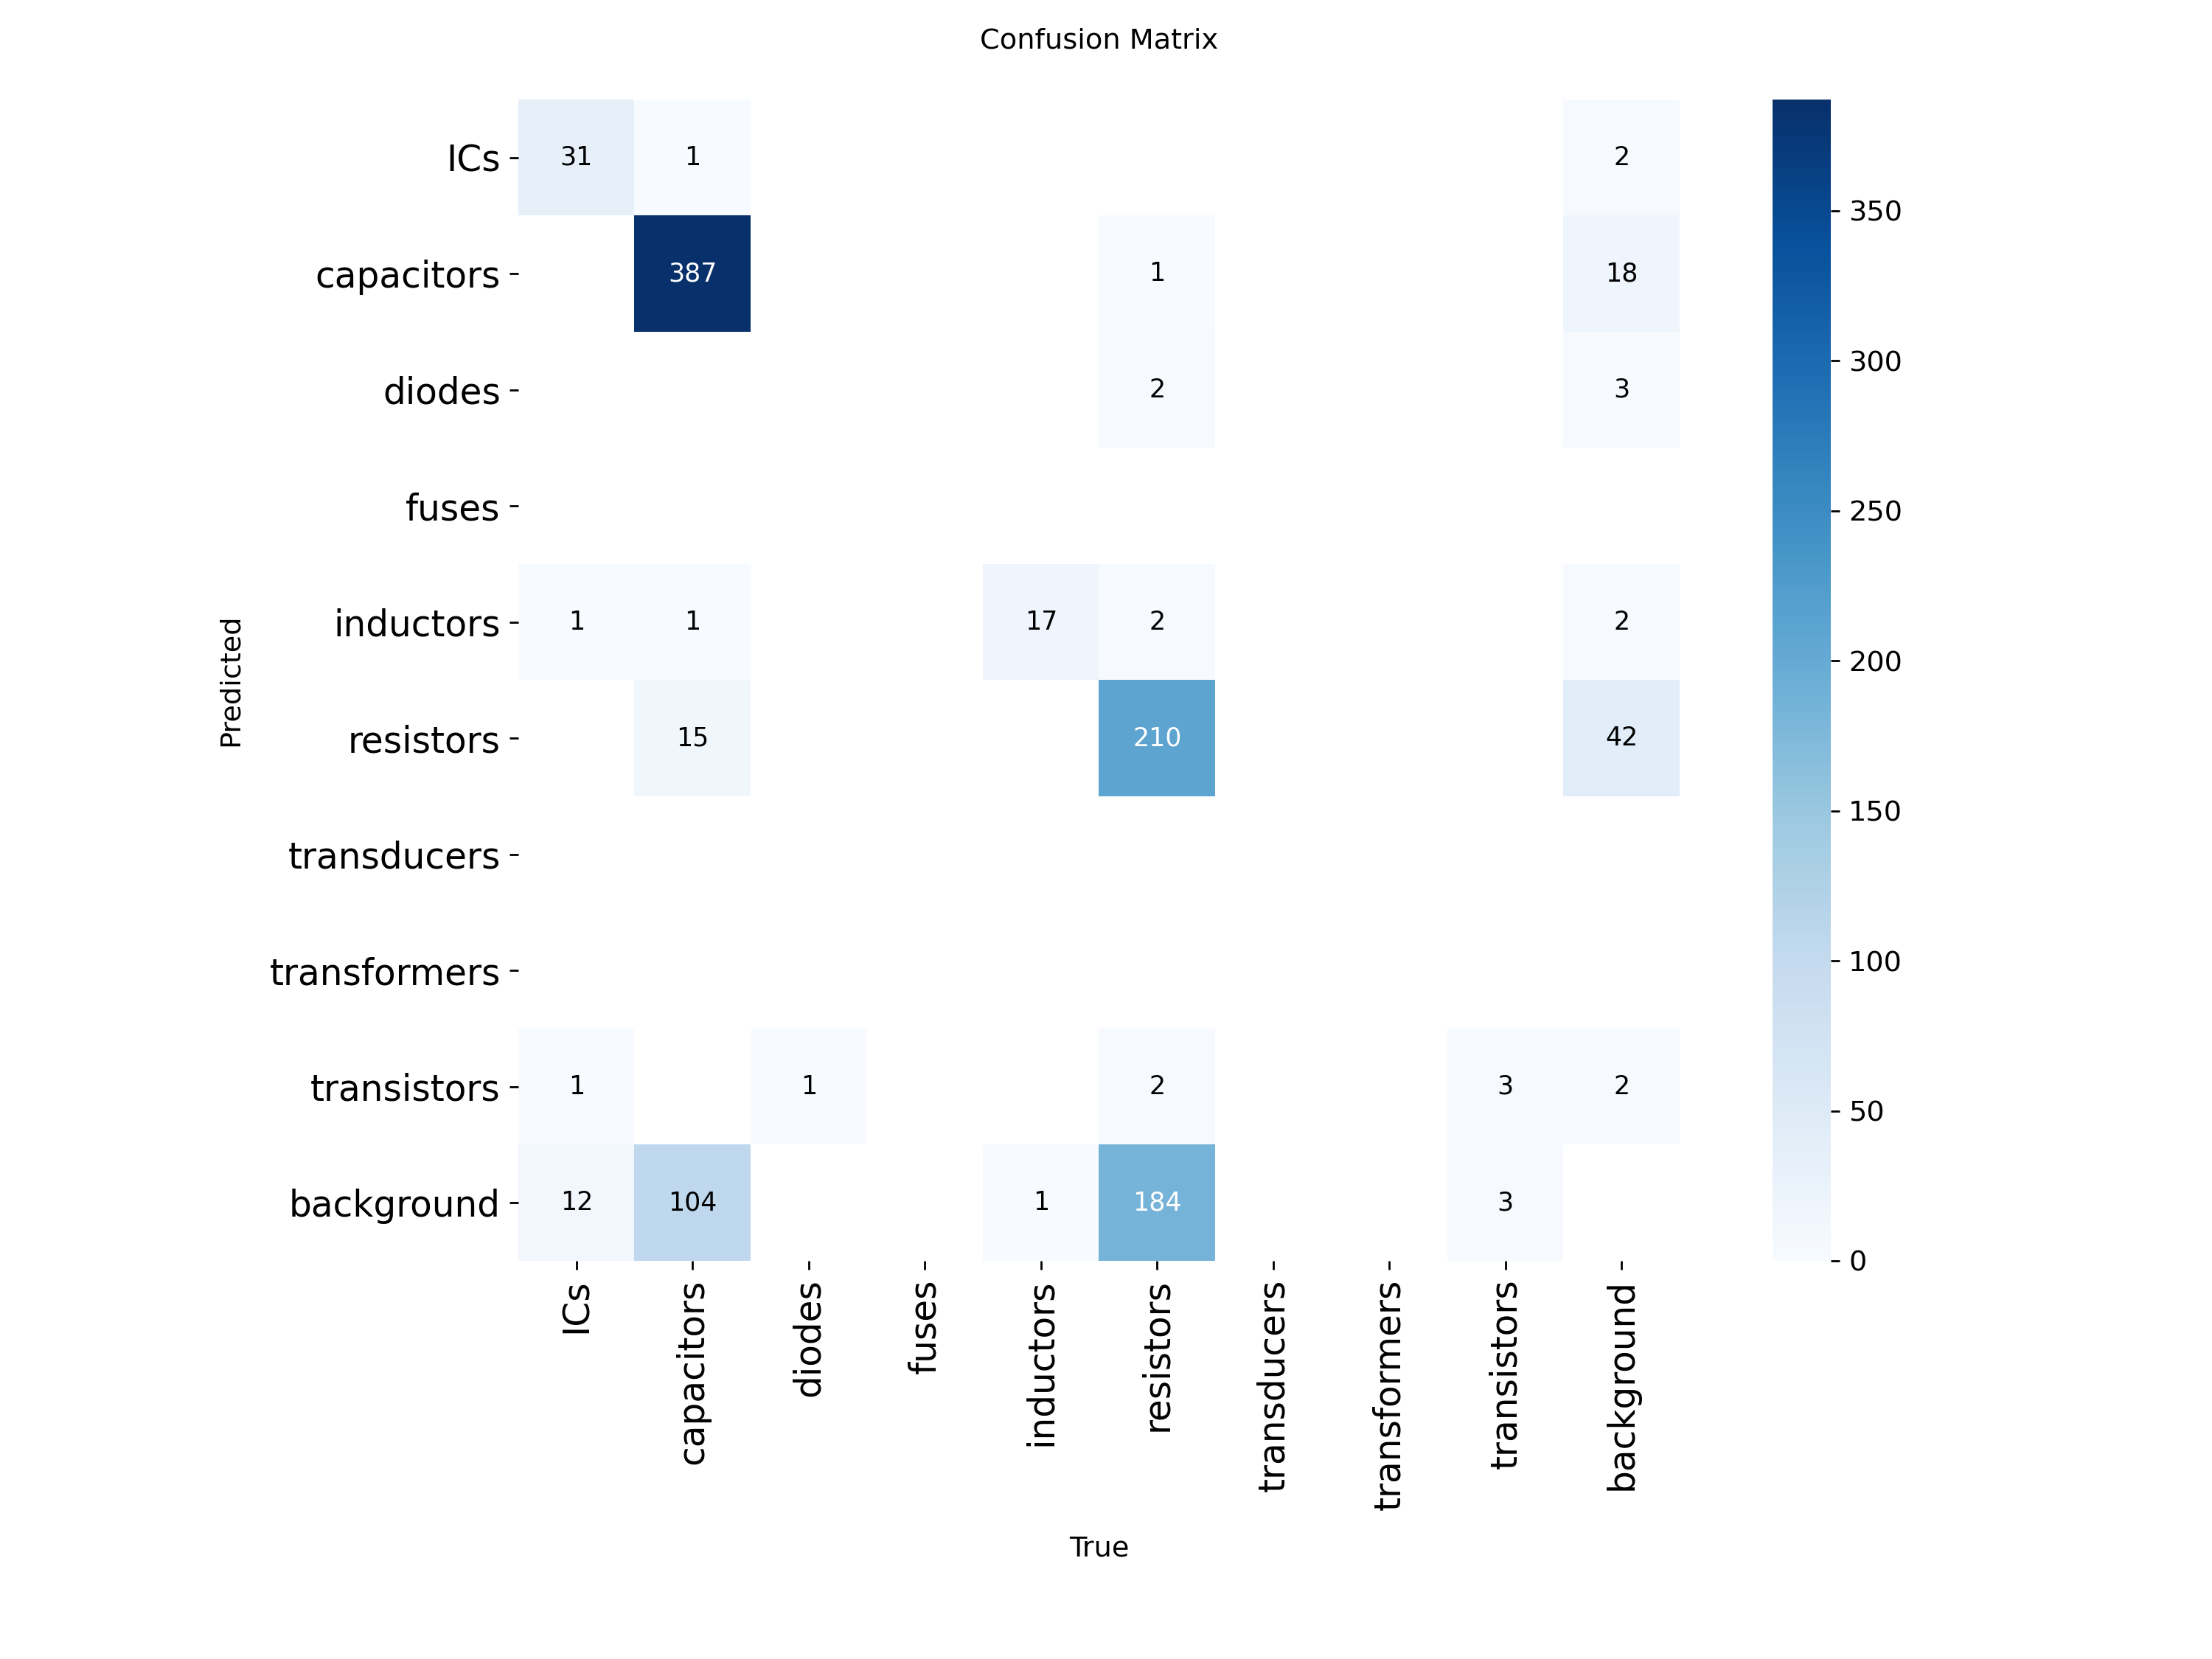

In [4]:
import os
import glob
import pandas as pd
from IPython.display import Image, display

# 1. Dynamically locate the most recent training directory
run_dirs = glob.glob('runs/obb/train*') + glob.glob('runs/detect/train*')
if not run_dirs:
    raise FileNotFoundError("No training directories found.")
latest_run = max(run_dirs, key=os.path.getmtime)
print(f"Extracting analytical data from: {latest_run}")

# 2. Display tabular metrics (results.csv)
csv_path = os.path.join(latest_run, 'results.csv')
if os.path.exists(csv_path):
    print("\n--- Raw Metrics (Final 5 Epochs) ---")
    metrics_df = pd.read_csv(csv_path)
    # Strip whitespace from column names for cleaner data manipulation if needed later
    metrics_df.columns = metrics_df.columns.str.strip()
    display(metrics_df.tail())

# 3. Filter and display visual evaluation plots
# Filtering against 'train_batch' or 'val_batch' keeps the output focused purely on metrics
plot_files = glob.glob(os.path.join(latest_run, '*.png'))
target_keywords = ['results', 'confusion_matrix', 'curve']

analytical_plots = [
    f for f in plot_files
    if any(keyword in os.path.basename(f).lower() for keyword in target_keywords)
]

for plot_path in analytical_plots:
    file_name = os.path.basename(plot_path)
    print(f"\n--- Visual Plot: {file_name} ---")
    display(Image(filename=plot_path, width=800))

In [5]:
import os
import glob
import shutil
from IPython.display import FileLink, display

# 1. Find all training directories
runs = glob.glob('runs/obb/train*') + glob.glob('runs/detect/train*')

if runs:
    # 2. Automatically select the most recent training run
    latest_run = max(runs, key=os.path.getmtime)
    print(f"Zipping the latest run results from: {latest_run}")

    # 3. Zip the folder
    shutil.make_archive('yolo_latest_results', 'zip', latest_run)
    print("Archive created successfully! Click the link below to download:")
    display(FileLink('yolo_latest_results.zip'))
else:
    print("No training run directories found under runs/obb/ or runs/detect/.")


Zipping the latest run results from: runs/obb/train-8
Archive created successfully! Click the link below to download:


/content/yolo_latest_results.zip